In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Qiskit primitives
from qiskit.primitives import StatevectorEstimator

# Algorithms
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA

# Ansatz
from qiskit.circuit.library import n_local

# Qiskit Nature
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.circuit.library import HartreeFock

# --- Setup ---
mapper = JordanWignerMapper()
estimator = StatevectorEstimator()
from qiskit_algorithms.optimizers import SLSQP
optimizer = SLSQP(maxiter=300)
# optimizer = COBYLA(maxiter=100)

distances_LiH = np.linspace(0.4, 3.0, 30)
energies_LiH = []

initial_point = None

for d in distances_LiH:
    # --- Molecule ---
    mol = MoleculeInfo(
        symbols=["Li", "H"],
        coords=[(0.0, 0.0, -d/2), (0.0, 0.0, d/2)],
        multiplicity=1,
        charge=0,
    )

    # --- Driver ---
    driver = PySCFDriver.from_molecule(molecule=mol, basis="sto3g")
    prob = driver.run()

    # --- Freeze core ---
    prob = FreezeCoreTransformer(freeze_core=True).transform(prob)

    # --- Active space ---
    prob = ActiveSpaceTransformer(
        num_electrons=2,
        num_spatial_orbitals=4
    ).transform(prob)

    # --- Hamiltonian ---
    ham = prob.hamiltonian.second_q_op()
    qubit_op = mapper.map(ham)

    # --- Hartree-Fock initial state ---
    hf = HartreeFock(
        num_spatial_orbitals=prob.num_spatial_orbitals,
        num_particles=prob.num_particles,
        qubit_mapper=mapper,
    )

    # --- Hardware-efficient ansatz ---
    he_ansatz = n_local(
        num_qubits=qubit_op.num_qubits,
        rotation_blocks=["ry", "rz"],
        entanglement_blocks="cx",
        entanglement="full",
        reps=3   # optimal range
    )

    # --- Combine HF + ansatz ---
    ansatz = hf.compose(he_ansatz)

    # --- VQE ---
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer
    )

    # Warm start
    if initial_point is not None:
        vqe.initial_point = initial_point

    result = vqe.compute_minimum_eigenvalue(qubit_op)
    initial_point = result.optimal_point

    # --- Energy ---
    total_energy = prob.interpret(result).total_energies[0]
    energies_LiH.append(total_energy)





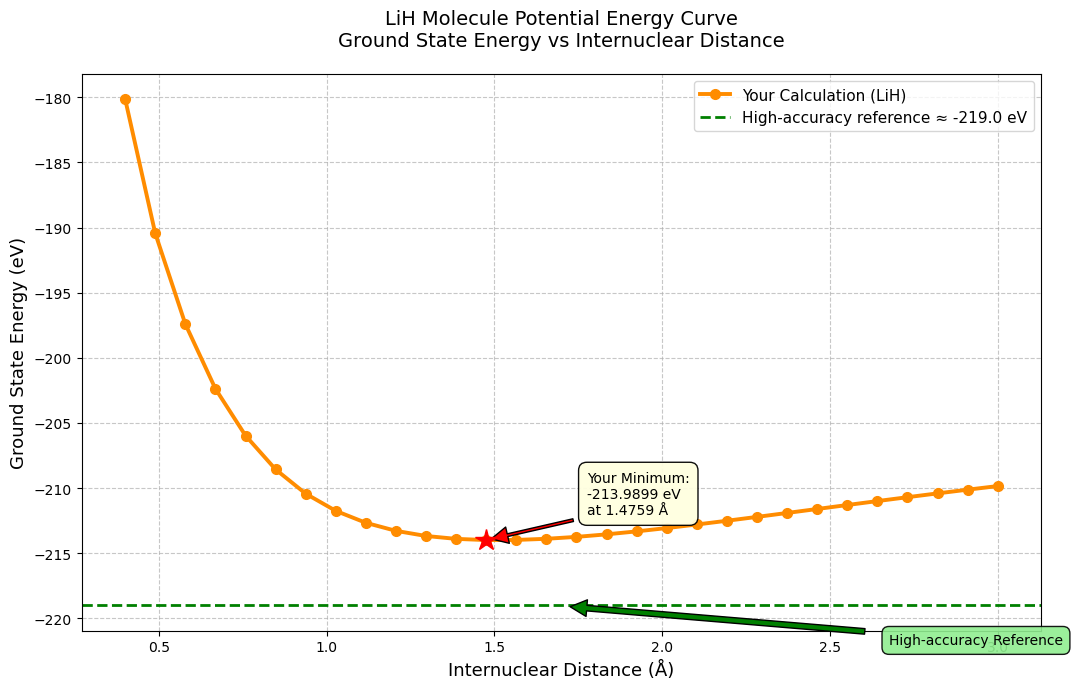

=== LiH RESULTS ===
Your Minimum ground state energy : -213.98991 eV
Your Equilibrium bond distance    : 1.4759 Å

Reference values:
Experimental bond length          : 1.595 Å
High-accuracy energy (approx)     : -219.00 eV


In [5]:

HARTREE_TO_EV = 27.21138602

# Convert your energies to eV
energies_ev = [e * HARTREE_TO_EV for e in energies_LiH]

# Find minimum from your data
min_energy_ev = min(energies_ev)
min_index = energies_ev.index(min_energy_ev)
eq_distance = distances_LiH[min_index]

# ====================== REFERENCE VALUES ======================
EXACT_ENERGY_EV = -219.0      # Approximate high-accuracy value (around -8.07 Ha)
EXACT_DISTANCE = 1.595        # Experimental equilibrium bond length (Å)

# ====================== PLOTTING ======================
plt.figure(figsize=(11, 7))

# Your calculation curve
plt.plot(distances_LiH, energies_ev, 'o-', 
         color='darkorange', 
         markersize=7, 
         linewidth=2.8, 
         label='Your Calculation (LiH)')

# Highlight your minimum
plt.plot(eq_distance, min_energy_ev, 'r*', markersize=16, zorder=5)

# Ideal / Reference line
plt.axhline(y=EXACT_ENERGY_EV, color='green', linestyle='--', linewidth=2,
            label=f'High-accuracy reference ≈ {EXACT_ENERGY_EV:.1f} eV')

# Annotations
plt.annotate(f'Your Minimum:\n{min_energy_ev:.4f} eV\nat {eq_distance:.4f} Å',
             xy=(eq_distance, min_energy_ev),
             xytext=(eq_distance + 0.3, min_energy_ev + 2),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2),
             bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow", alpha=0.95))

plt.annotate('High-accuracy Reference',
             xy=(eq_distance + 0.2, EXACT_ENERGY_EV),
             xytext=(eq_distance + 1.2, EXACT_ENERGY_EV - 3),
             arrowprops=dict(facecolor='green', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.9))

# Labels and Title
plt.xlabel("Internuclear Distance (Å)", fontsize=13)
plt.ylabel("Ground State Energy (eV)", fontsize=13)

plt.title("LiH Molecule Potential Energy Curve\nGround State Energy vs Internuclear Distance", 
          fontsize=14, pad=20)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# ====================== RESULTS ======================
print("=== LiH RESULTS ===")
print(f"Your Minimum ground state energy : {min_energy_ev:.5f} eV")
print(f"Your Equilibrium bond distance    : {eq_distance:.4f} Å")
print(f"\nReference values:")
print(f"Experimental bond length          : {EXACT_DISTANCE:.3f} Å")
print(f"High-accuracy energy (approx)     : {EXACT_ENERGY_EV:.2f} eV")

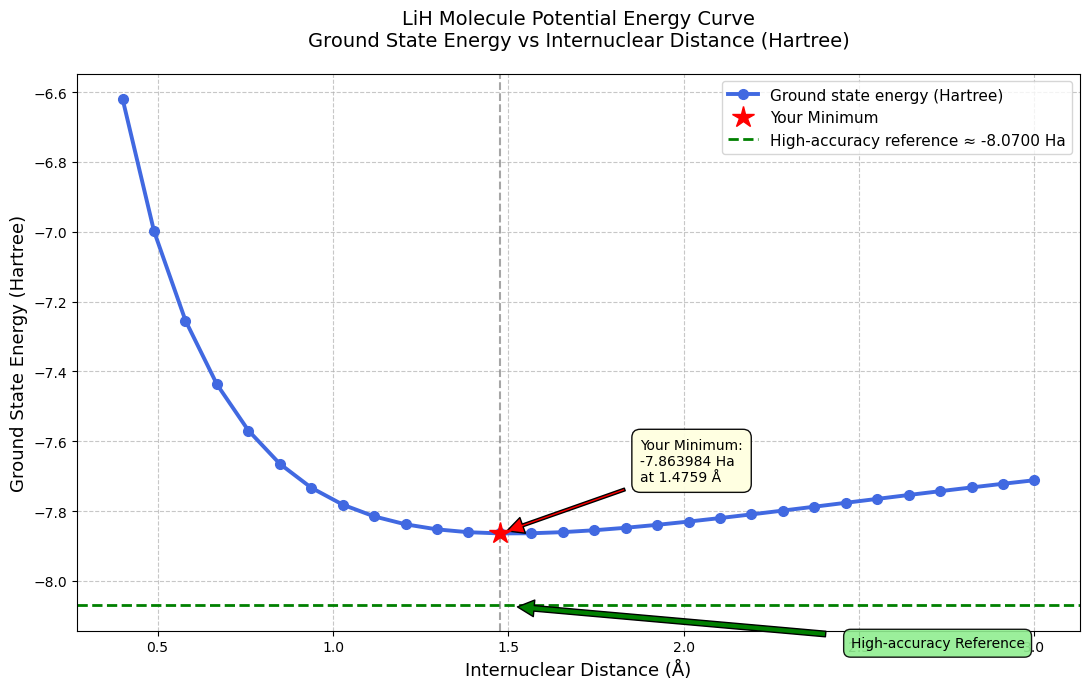

=== LiH RESULTS (Hartree) ===
Minimum ground state energy : -7.86398427 Ha
Equilibrium bond distance    : 1.4759 Å

Reference:
Experimental bond length     : 1.595 Å
High-accuracy energy         : -8.0700 Ha


In [7]:

# ====================== REFERENCE VALUES ======================
EXACT_ENERGY_HA = -8.070   # Approximate high-accuracy value
EXACT_DISTANCE = 1.595     # Experimental equilibrium bond length (Å)

# ====================== FIND MINIMUM ======================
min_energy_ha = min(energies_LiH)
min_index = energies_LiH.index(min_energy_ha)
eq_distance = distances_LiH[min_index]

# ====================== PLOTTING ======================
plt.figure(figsize=(11, 7))

# Main plot
plt.plot(distances_LiH, energies_LiH, 'o-', 
         color='royalblue', 
         markersize=7, 
         linewidth=2.8, 
         label='Ground state energy (Hartree)')

# Highlight your minimum
plt.plot(eq_distance, min_energy_ha, 'r*', markersize=16, zorder=5,
         label=f'Your Minimum')

# Reference line
plt.axhline(y=EXACT_ENERGY_HA, color='green', linestyle='--', linewidth=2,
            label=f'High-accuracy reference ≈ {EXACT_ENERGY_HA:.4f} Ha')

# Vertical line at equilibrium
plt.axvline(x=eq_distance, color='gray', linestyle='--', alpha=0.7)

# Annotations
plt.annotate(f'Your Minimum:\n{min_energy_ha:.6f} Ha\nat {eq_distance:.4f} Å',
             xy=(eq_distance, min_energy_ha),
             xytext=(eq_distance + 0.4, min_energy_ha + 0.15),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2),
             bbox=dict(boxstyle="round,pad=0.6", facecolor="lightyellow", alpha=0.95))

plt.annotate('High-accuracy Reference',
             xy=(eq_distance, EXACT_ENERGY_HA),
             xytext=(eq_distance + 1.0, EXACT_ENERGY_HA - 0.12),
             arrowprops=dict(facecolor='green', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.9))

# Labels and Title
plt.xlabel("Internuclear Distance (Å)", fontsize=13)
plt.ylabel("Ground State Energy (Hartree)", fontsize=13)

plt.title("LiH Molecule Potential Energy Curve\nGround State Energy vs Internuclear Distance (Hartree)", 
          fontsize=14, pad=20)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

# ====================== RESULTS ======================
print("=== LiH RESULTS (Hartree) ===")
print(f"Minimum ground state energy : {min_energy_ha:.8f} Ha")
print(f"Equilibrium bond distance    : {eq_distance:.4f} Å")
print(f"\nReference:")
print(f"Experimental bond length     : {EXACT_DISTANCE:.3f} Å")
print(f"High-accuracy energy         : {EXACT_ENERGY_HA:.4f} Ha")